# Trabajo 3 - Grupo 6  

**Curso:** INTRODUCCIÓN A CIENCIA DE DATOS Y MACHINE LEARNING CON PYTHON  
**Profesor:** Luis Zapata Bobadilla  

---

## Integrantes
- Carmen Crisanto, César Jair  
- Miranda Sanchez, Alex Abraham Patrick  
- Prado Chafloque, Sarai Elizabeth  
- Reategui Zapata, Joaquin Alejandro  

---

## Pregunta de investigación
**¿Cómo influye el déficit fiscal en las expectativas empresariales de corto plazo (3 meses) y largo plazo (12 meses)?**  


## Objetivo
Ampliar la base de variables y aplicar Análisis de Componentes Principales (PCA) para explorar la estructura
de los datos. Se busca comparar distintos modelos —según el tipo de problema—, validar correctamente sus resultados
y reportar métricas adecuadas. En tareas de clasificación, deberán además cuantificar los costos asociados a falsos
positivos y negativos para definir un umbral óptimo de decisión.



Se consulta al API del Banco Central de Reserva del Perú para obtener las seis series mensuales:

- PN39524FM: Déficit fiscal  
- PD38045AM: Expectativas de la economía a 3 meses  
- PD37981AM: Expectativas de la economía a 12 meses  
- PD04722MM: Tasa de referencia  
- PN02409FM: Gasto no financiero total  
- PN01129XM: EMBIG Perú  


Las fechas se transforman a un formato estándar (por ejemplo, `Ene.2020` se convierte en `2020-01-01`) y los valores numéricos se limpian, convirtiendo “n.d.” o cadenas vacías en valores faltantes (`NaN`). El API del BCRP no siempre responde con la misma estructura, así que se incluyen dos rutas de lectura dependiendo de si aparece la clave `periods` o `series`.

Luego se forma un DataFrame, y se reindexa a todos los meses del periodo 2015–2025 para asegurar continuidad temporal, incluso en meses sin datos. Finalmente, se renombran las columnas con nombres más claros (por ejemplo, `PN39524FM` pasa a `deficit_fiscal`).

Al final se imprimen algunos elementosl: la URL consultada, las dimensiones finales, las columnas presentes, el número de nulos por serie y una vista inicial y final del DataFrame.


In [ ]:
import requests, json, pandas as pd, numpy as np, re

series = [
    "PN39524FM",  # Déficit fiscal
    "PD38045AM",  # Expectativas economía 3m
    "PD37981AM",  # Expectativas economía 12m
    "PD04722MM",  # Tasa de referencia
    "PN02409FM",   # Gasto No Financiero Total
    "PN01129XM",  # EMBIG - Perú
]
inicio = "2015-01"
fin    = "2025-12"

codigos = "-".join(series)
url = f"https://estadisticas.bcrp.gob.pe/estadisticas/series/api/{codigos}/json/{inicio}/{fin}"
r = requests.get(url, timeout=30)
r.raise_for_status()

try:
    data = r.json()
except json.JSONDecodeError:
    data = json.loads(r.text.lstrip("\ufeff").strip())

MESES = {'Ene':'01','Feb':'02','Mar':'03','Abr':'04','May':'05','Jun':'06',
         'Jul':'07','Ago':'08','Sep':'09','Oct':'10','Nov':'11','Dic':'12'}
def parse_fecha(s):
    s = str(s).strip()
    m = re.match(r'^([A-Za-zÁÉÍÓÚÑáéíóúñ]{3})\.(\d{4})$', s)
    if m:
        mm = MESES.get(m.group(1).title())
        return pd.to_datetime(f"{m.group(2)}-{mm}-01", errors="coerce")
    return pd.to_datetime(s, errors="coerce", dayfirst=False)

def to_float(x):
    if x in (None, 'n.d.', 'NaN', ''):
        return np.nan
    try:
        return float(x)
    except Exception:
        return np.nan

if isinstance(data, dict) and 'periods' in data:

    meta_series = []
    cfg = data.get('config', {})
    if isinstance(cfg, dict) and isinstance(cfg.get('series'), list) and cfg['series']:

        if 'code' in cfg['series'][0]:
            meta_series = [s.get('code') for s in cfg['series']]
        else:

            meta_series = [s.get('name') for s in cfg['series']]
    if not meta_series:

        meta_series = series

    rows = []
    for per in data['periods']:
        fecha = parse_fecha(per.get('name'))
        vals = per.get('values', [])
        # normalizar longitud (pad/trunc)
        if len(vals) < len(meta_series):
            vals = vals + [None] * (len(meta_series) - len(vals))
        elif len(vals) > len(meta_series):
            vals = vals[:len(meta_series)]
        row = {'date': fecha}
        for col, v in zip(meta_series, vals):
            row[col] = to_float(v)
        rows.append(row)

    df = pd.DataFrame(rows).set_index('date').sort_index()

elif isinstance(data, dict) and 'series' in data:

    rows = {}
    for s in data['series']:
        code = s.get('code') or s.get('codigo') or s.get('name')
        for p in s.get('periods', []):
            fecha = parse_fecha(p.get('name'))
            val_list = p.get('values', [None])
            val = to_float(val_list[0] if isinstance(val_list, list) and val_list else val_list)
            rows.setdefault(fecha, {})[code] = val
    df = pd.DataFrame.from_dict(rows, orient='index').sort_index()

else:
    raise ValueError("Respuesta del API no reconocida (sin 'periods' ni 'series').")

# ===== Reindex mensual 2015-01..2025-12 y alias =====
idx = pd.date_range(start="2015-01-01", end="2025-12-01", freq="MS")
df = df.reindex(idx)
df.index.name = "date"

alias = {
    "PN39524FM":"deficit_fiscal",
    "PD38045AM":"exp_eco_3m",
    "PD37981AM":"exp_eco_12m",
    "PD04722MM":"tasa_ref",
    "PN2409FM":"gasto_no_financiero",
    "PN01129XM":"embig_pe"
}
# solo renombrar las columnas que existan
rename_map = {k:v for k,v in alias.items() if k in df.columns}
df = df.rename(columns=rename_map)

print("URL:", url)
print("Dimensiones:", df.shape)
print("Columnas:", list(df.columns))
print("Nulos por serie:\n", df.isna().sum())
display(df.head(10))
display(df.tail(10))


URL: https://estadisticas.bcrp.gob.pe/estadisticas/series/api/PN39524FM-PD38045AM-PD37981AM-PD04722MM-PN02409FM-PN01129XM/json/2015-01/2025-12
Dimensiones: (132, 6)
Columnas: ['Tasas de interés del Banco Central de Reserva - Tasa de Referencia de la Política Monetaria', 'Expectativas empresariales totales - Índice de expectativas de la economía a 12 meses', 'Expectativas empresariales totales - Índice de expectativas de la economía a 3 meses', 'Indicadores de riesgo para países emergentes: EMBIG - Diferencial de Rendimientos del Índice de Bonos de Mercados Emergentes (EMBIG) - Perú', 'Gastos no financieros del gobierno general (millones S/) - Gasto No Financiero Total', 'Operaciones del sector público no financiero (millones S/) - Resultado económico (Acumulado 12 meses - Porcentaje del PBI)']
Nulos por serie:
 Tasas de interés del Banco Central de Reserva - Tasa de Referencia de la Política Monetaria                                                    2
Expectativas empresariales total

,Tasas de interés del Banco Central de Reserva - Tasa de Referencia de la Política Monetaria,Expectativas empresariales totales - Índice de expectativas de la economía a 12 meses,Expectativas empresariales totales - Índice de expectativas de la economía a 3 meses,Indicadores de riesgo para países emergentes: EMBIG - Diferencial de Rendimientos del Índice de Bonos de Mercados Emergentes (EMBIG) - Perú,Gastos no financieros del gobierno general (millones S/) - Gasto No Financiero Total,Operaciones del sector público no financiero (millones S/) - Resultado económico (Acumulado 12 meses - Porcentaje del PBI)
date,,,,,,
2015-01-01,3.25,65.189873,54.231975,201.22727,6684.120041,-0.269609
2015-02-01,3.25,60.534591,50.157729,182.85000,8002.039354,-0.333748
2015-03-01,3.25,56.060606,49.388379,184.45455,8862.718910,-0.399409
2015-04-01,3.25,55.539773,46.742210,176.95455,9620.291792,-0.681990
2015-05-01,3.25,53.835227,45.070423,165.90476,9377.253592,-0.871407
2015-06-01,3.25,55.414013,50.625000,176.50000,10177.834085,-0.935100
2015-07-01,3.25,54.057592,46.719160,186.69565,11487.196216,-0.904423
2015-08-01,3.25,49.262899,42.222222,217.47619,9654.999728,-0.996294
2015-09-01,3.50,50.639386,43.222506,234.27273,10640.494378,-1.332746


,Tasas de interés del Banco Central de Reserva - Tasa de Referencia de la Política Monetaria,Expectativas empresariales totales - Índice de expectativas de la economía a 12 meses,Expectativas empresariales totales - Índice de expectativas de la economía a 3 meses,Indicadores de riesgo para países emergentes: EMBIG - Diferencial de Rendimientos del Índice de Bonos de Mercados Emergentes (EMBIG) - Perú,Gastos no financieros del gobierno general (millones S/) - Gasto No Financiero Total,Operaciones del sector público no financiero (millones S/) - Resultado económico (Acumulado 12 meses - Porcentaje del PBI)
date,,,,,,
2025-03-01,4.75,58.075601,53.934426,163.354839,18005.990410,-3.280453
2025-04-01,4.75,57.903780,52.131148,177.571429,17353.876008,-2.843629
2025-05-01,4.50,56.890459,53.965517,158.580645,18796.515236,-2.631968
2025-06-01,4.50,56.644518,52.903226,153.833333,19656.821838,-2.561810
2025-07-01,4.50,58.305648,54.545455,140.612903,21381.876944,-2.557674
2025-08-01,4.50,60.147601,54.432624,133.322581,19399.541675,-2.366019
2025-09-01,4.25,61.091549,55.631399,124.107143,20786.707593,-2.373910
2025-10-01,4.25,60.954064,55.892256,NaN,NaN,NaN
2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN


Estandarización de nombres y orden final de las series

Las series descargadas del BCRP vienen con nombres muy largos y difíciles de manejar. Para simplificar el análisis, se asignan nombres más breves y claros a cada variable (por ejemplo, la serie del déficit fiscal pasa a llamarse simplemente `deficit_fiscal`).  

Después del renombrado, se organiza el DataFrame:
1. Déficit fiscal  
2. Expectativas a 3 meses  
3. Expectativas a 12 meses  
4. Tasa de referencia  
5. Gasto no financiero  
6. EMBIG Perú  

Finalmente, se muestran las columnas resultantes y una vista de las primeras y últimas observaciones para verificar que la estructura sea correcta.


In [ ]:
rename_map = {
    "Operaciones del sector público no financiero (millones S/) - Resultado económico (Acumulado 12 meses - Porcentaje del PBI)": "deficit_fiscal",
    "Expectativas empresariales totales - Índice de expectativas de la economía a 3 meses": "exp_eco_3m",
    "Expectativas empresariales totales - Índice de expectativas de la economía a 12 meses": "exp_eco_12m",
    "Tasas de interés del Banco Central de Reserva - Tasa de Referencia de la Política Monetaria": "tasa_ref",
    "Gastos no financieros del gobierno general (millones S/) - Gasto No Financiero Total": "gasto_no_financiero",
    "Indicadores de riesgo para países emergentes: EMBIG - Diferencial de Rendimientos del Índice de Bonos de Mercados Emergentes (EMBIG) - Perú": "embig_pe"
}

df = df.rename(columns=rename_map)

# Orden lógico de columnas
orden = ["deficit_fiscal", "exp_eco_3m", "exp_eco_12m", "tasa_ref", "gasto_no_financiero", "embig_pe"]
df = df[[c for c in orden if c in df.columns]]

print("Columnas finales:", list(df.columns))
display(df.head(5))
display(df.tail(5))

Columnas finales: ['deficit_fiscal', 'exp_eco_3m', 'exp_eco_12m', 'tasa_ref', 'gasto_no_financiero', 'embig_pe']


,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref,gasto_no_financiero,embig_pe
date,,,,,,
2015-01-01,-0.269609,54.231975,65.189873,3.25,6684.120041,201.22727
2015-02-01,-0.333748,50.157729,60.534591,3.25,8002.039354,182.85000
2015-03-01,-0.399409,49.388379,56.060606,3.25,8862.718910,184.45455
2015-04-01,-0.681990,46.742210,55.539773,3.25,9620.291792,176.95455
2015-05-01,-0.871407,45.070423,53.835227,3.25,9377.253592,165.90476


,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref,gasto_no_financiero,embig_pe
date,,,,,,
2025-08-01,-2.366019,54.432624,60.147601,4.50,19399.541675,133.322581
2025-09-01,-2.373910,55.631399,61.091549,4.25,20786.707593,124.107143
2025-10-01,NaN,55.892256,60.954064,4.25,NaN,NaN
2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-01,NaN,NaN,NaN,NaN,NaN,NaN



Antes de avanzar con cualquier análisis, es importante verificar cuántos datos faltan en cada variable, lo que nos permite identificar si algunas series del BCRP tienen interrupciones, meses sin reporte o valores no disponibles que podrían afectar los gráficos o las regresiones posteriores.



In [ ]:
print("Cantidad de valores nulos por variable:")
print(df.isna().sum())

Cantidad de valores nulos por variable:
deficit_fiscal         3
exp_eco_3m             2
exp_eco_12m            2
tasa_ref               2
gasto_no_financiero    3
embig_pe               3
dtype: int64


Se ajusta el DataFrame para trabajar únicamente hasta septiembre de 2025.  
Esto se hace porque, aunque la API permite consultar datos hasta diciembre, varias series no tienen información completa para los meses finales del año.  
Al limitar el rango, se evita trabajar con observaciones futuras vacías y se mantiene la consistencia entre todas las variables.


In [ ]:
df = df.loc[df.index <= "2025-09-01"]

print("Última fecha del DataFrame:", df.index.max().strftime("%Y-%m"))
display(df.tail(10))

Última fecha del DataFrame: 2025-09


,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref,gasto_no_financiero,embig_pe
date,,,,,,
2024-12-01,-3.458219,50.000000,56.521739,5.00,31009.860546,154.380952
2025-01-01,-3.569031,52.592593,58.206107,4.75,16630.174544,156.761905
2025-02-01,-3.446920,54.545455,60.658915,4.75,16353.706657,158.250000
2025-03-01,-3.280453,53.934426,58.075601,4.75,18005.990410,163.354839
2025-04-01,-2.843629,52.131148,57.903780,4.75,17353.876008,177.571429
2025-05-01,-2.631968,53.965517,56.890459,4.50,18796.515236,158.580645
2025-06-01,-2.561810,52.903226,56.644518,4.50,19656.821838,153.833333
2025-07-01,-2.557674,54.545455,58.305648,4.50,21381.876944,140.612903
2025-08-01,-2.366019,54.432624,60.147601,4.50,19399.541675,133.322581


In [ ]:
print("Cantidad de valores nulos por variable:")
print(df.isna().sum())

Cantidad de valores nulos por variable:
deficit_fiscal         0
exp_eco_3m             0
exp_eco_12m            0
tasa_ref               0
gasto_no_financiero    0
embig_pe               0
dtype: int64


In [ ]:
ruta_salida = r"C:\Users\LENOVO\Desktop\UDEP-ECONOMIA\CICLO X\ICD\TRABAJO 3\bcrp_series_2015_2025.csv"

df.to_csv(ruta_salida, index=True, encoding="utf-8-sig")

print(f"Archivo CSV exportado correctamente en:\n{ruta_salida}")

Archivo CSV exportado correctamente en:
C:\Users\LENOVO\Desktop\UDEP-ECONOMIA\CICLO X\ICD\TRABAJO 3\bcrp_series_2015_2025.csv


Se importan todas las librerías necesarias para el análisis: manejo de datos (NumPy y pandas), visualización (matplotlib), modelos (Ridge, Lasso, Random Forest y XGBoost), validación temporal (TimeSeriesSplit), escalamiento, PCA y métricas.

También se fija una semilla aleatoria (`RANDOM_STATE = 42`) para asegurar que los resultados sean reproducibles en cada ejecución.  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (7,4)


En este paso se carga el archivo CSV.
Se utiliza `parse_dates` para leer la columna **date** directamente como tipo fecha y luego se ordenan las observaciones cronológicamente y se establece la fecha como índice temporal del DataFrame y se muestran las primeras filas para verificar.

In [ ]:
ruta = r"C:\Users\LENOVO\Desktop\UDEP-ECONOMIA\CICLO X\ICD\TRABAJO 3\bcrp_series_2015_2025.csv"

df = pd.read_csv(ruta, parse_dates=['date'])
df = df.sort_values('date').set_index('date')

print("Columnas disponibles:", df.columns.tolist())
display(df.head(3))


Columnas disponibles: ['deficit_fiscal', 'exp_eco_3m', 'exp_eco_12m', 'tasa_ref', 'gasto_no_financiero', 'embig_pe']


,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref,gasto_no_financiero,embig_pe
date,,,,,,
2015-01-01,-0.269609,54.231975,65.189873,3.25,6684.120041,201.22727
2015-02-01,-0.333748,50.157729,60.534591,3.25,8002.039354,182.85000
2015-03-01,-0.399409,49.388379,56.060606,3.25,8862.718910,184.45455


### 2) Ingeniería de variables: construcción del set predictivo

En este bloque se definen los **targets** (`exp_eco_3m` y `exp_eco_12m`) que representan las expectativas empresariales a corto y largo plazo, respectivamente. Los **predictores base** son variables macroeconómicas claves (`deficit_fiscal`, `embig_pe`, `tasa_ref` y `gasto_no_financiero`) vinculadas a la sostenibilidad fiscal y la percepción de riesgo.  
A partir de ellas, se generan **rezagos** de 1 y 3 periodos (`_l1`, `_l3`) y **diferencias primeras (`d_`)** para capturar inercia temporal y cambios recientes sin usar información futura. Además, se incorporan **interacciones no lineales** —como `deficit_x_embi` y `deficit_x_tasa`— para reflejar cómo el efecto del déficit puede depender del riesgo país o de la política monetaria.  
Por último, se crea una **variable de régimen (`reg_embi_high`)** que marca episodios de alto riesgo externo (EMBI elevado) y una interacción asociada (`deficit_x_reg`), permitiendo estudiar si la relación fiscal-expectativas cambia bajo estrés financiero.  
Finalmente, se eliminan los valores perdidos derivados de los rezagos, dejando la base lista para estimar y comparar modelos lineales penalizados (Ridge/Lasso) y no lineales (Random Forest/XGBoost) con validación temporal.


In [ ]:
# Targets
targets = [c for c in ['exp_eco_3m','exp_eco_12m'] if c in df.columns]

# Predictores base disponibles
base_feats = [c for c in ['deficit_fiscal','embig_pe','tasa_ref','gasto_no_financiero'] if c in df.columns]

# Lags y diferencias (evita fuga de info)
for col in base_feats + targets:
    df[f'{col}_l1'] = df[col].shift(1)
    df[f'{col}_l3'] = df[col].shift(3)
    df[f'd_{col}']  = df[col].diff(1)

# Interacciones sugeridas por el feedback del T2
if set(['deficit_fiscal','embig_pe']).issubset(df.columns):
    df['deficit_x_embi'] = df['deficit_fiscal'] * df['embig_pe']
if set(['deficit_fiscal','tasa_ref']).issubset(df.columns):
    df['deficit_x_tasa'] = df['deficit_fiscal'] * df['tasa_ref']

# Proxy de régimen: EMBI alto
if 'embig_pe' in df.columns:
    thr_embi = df['embig_pe'].quantile(0.75)
    df['reg_embi_high'] = (df['embig_pe'] >= thr_embi).astype(int)
    if 'deficit_fiscal' in df.columns:
        df['deficit_x_reg'] = df['deficit_fiscal'] * df['reg_embi_high']

# Limpieza por NAs introducidos
df = df.dropna().copy()
print("Filas tras ingeniería:", len(df))


Filas tras ingeniería: 126


## 3) Análisis exploratorio con PCA (Análisis de Componentes Principales)

El Análisis de Componentes Principales (PCA) permite reducir la dimensionalidad del conjunto de variables predictoras, transformándolas en componentes ortogonales que concentran la mayor parte de la variabilidad original. Esta técnica es fundamental para identificar y abordar la multicolinealidad, que ocurre cuando las variables están altamente correlacionadas y aportan información redundante.

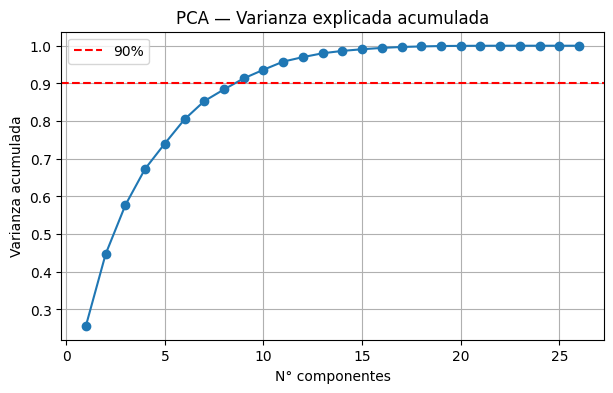

In [ ]:
X_pca_cols = [c for c in df.columns if c not in ['exp_eco_3m','exp_eco_12m']]
X_pca = df[X_pca_cols].copy()

pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=None, random_state=RANDOM_STATE))
])
Z = pipe_pca.fit_transform(X_pca)
pca = pipe_pca.named_steps['pca']
cum_var = pca.explained_variance_ratio_.cumsum()

plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.90, color='r', ls='--', label='90%')
plt.title('PCA — Varianza explicada acumulada')
plt.xlabel('N° componentes'); plt.ylabel('Varianza acumulada')
plt.legend(); plt.grid(True); plt.show()


En el gráfico de varianza explicada acumulada, observamos que aproximadamente 10 componentes explican más del 90% de la varianza total de las variables independientes. Esto indica que la mayoría de la información contenida en las variables originales puede ser representada con un conjunto mucho más reducido de factores subyacentes.

Este resultado confirma que nuestras variables macroeconómicas, como el déficit fiscal, EMBI, tasa de referencia y gasto público, están altamente correlacionadas. En consecuencia, esto puede generar inestabilidades y dificultades en la estimación de modelos lineales clásicos debido a la multicolinealidad.

Por ello, esta exploración sirve de soporte para la elección de modelos penalizados, como Ridge y Lasso, que incorporan mecanismos para estabilizar las estimaciones y seleccionar variables relevantes cuando existe alta correlación entre predictores. Así, podemos obtener modelos más robustos y con mejor capacidad predictiva, evitando el sobreajuste.

En resumen, el PCA no solo ayuda a visualizar y entender la estructura de la información en las variables, sino que también orienta la selección de técnicas adecuadas para el modelado posterior.

## 4) Modelo base ("naive") — Enfoque de *random walk**




Ahora se construye un punto de referencia sencillo: un esquema de **random walk**, donde la mejor predicción de una variable económica para el siguiente mes es simplemente su valor del mes anterior. Este tipo de baseline es común en series temporales macroeconómicas, donde muchas variables muestran movimientos graduales.

Con este baseline se calcula el **MSE de prueba** para cada horizonte de expectativas empresariales. Ese valor sirve como piso mínimo que cualquier modelo debe mejorar para ser considerado útil.

Luego se preparan las matrices de variables explicativas (`X`) y (`y`). Las características se construyen combinando rezagos de cada serie (por ejemplo, lags de 1 y 3 meses) y diferencias mensuales. Esto permite capturar dinámicas de corto plazo y cambios en tendencia. También se incorporan interacciones económicas relevantes, como *déficit × EMBI*, que representan cómo las condiciones fiscales pueden verse amplificadas por el contexto financiero externo.

Posteriormente se estima los modelos:

- **Ridge**: útil cuando varias variables están correlacionadas, estabiliza los coeficientes.
- **Lasso**: realiza selección automática de variables, lo que ayuda a identificar los determinantes más importantes.
- **Random Forest**: permite capturar relaciones no lineales y posibles umbrales en la respuesta de las expectativas.
- **XGBoost**: un modelo más flexible y potente para detectar patrones no lineales y efectos interactivos.

Para cada caso se usa validación cruzada en ventanas temporales (`TimeSeriesSplit`), coherente con la naturaleza secuencial de los datos. Tras entrenar, se calcula el **Test MSE** y se comparan los resultados. Finalmente, se grafica la predicción del mejor modelo frente a los valores reales, lo que permite visualizar qué tan bien captura la dinámica de las expectativas.

Así se quiere evaluar si las expectativas empresariales responden a condiciones macroeconómicas recientes (fiscales, monetarias y financieras) de manera lineal o no lineal, y determinar qué modelo es más adecuado para anticipar su comportamiento.

In [ ]:
def baseline_naive_mse(df, target):
    # usa el mismo split que make_Xy (80/20)
    y = df[target].dropna()
    cut = int(len(y)*0.8)
    y_train, y_test = y.iloc[:cut], y.iloc[cut:]
    # predicción ingenua: y_t ≈ y_{t-1}
    yhat = y_test.shift(1)
    # alinear (la primera pred del test no tiene lag)
    y_test2 = y_test.iloc[1:]
    yhat2   = yhat.iloc[1:]
    return mean_squared_error(y_test2, yhat2)

for target in ['exp_eco_3m','exp_eco_12m']:
    if target in df.columns:
        print(target, "— Baseline naive Test MSE:", baseline_naive_mse(df, target))

exp_eco_3m — Baseline naive Test MSE: 4.090829497558997
exp_eco_12m — Baseline naive Test MSE: 8.402629016630037


In [ ]:
def make_Xy(df, target, base_feats):
    pool = []
    for col in base_feats + [target]:
        for suf in ['_l1','_l3','d_']:
            name = f'{col}{suf}' if suf=='d_' else f'{col}{suf}'
            if name in df.columns and not (name == f'd_{target}'):
                pool.append(name)
    for extra in ['deficit_x_embi','deficit_x_tasa','deficit_x_reg','reg_embi_high']:
        if extra in df.columns:
            pool.append(extra)
    feats = sorted(set(pool))
    X = df[feats].copy()
    y = df[target].copy()

    # split temporal 80/20
    cut = int(len(X)*0.8)
    return X.iloc[:cut], X.iloc[cut:], y.iloc[:cut], y.iloc[cut:], feats

def plot_real_vs_pred(y_test, y_hat, title):
    plt.plot(y_test.index, y_test.values, label='Real')
    plt.plot(y_test.index, y_hat, label='Pred')
    plt.title(title); plt.xlabel('Tiempo'); plt.ylabel(y_test.name)
    plt.legend(); plt.grid(True); plt.show()




MODELO PARA: exp_eco_3m
Ridge  | alpha*=24.24462 | Test MSE=21.227508
Lasso  | alpha*=0.58780 | Test MSE=11.102385
RF     | params={'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 300} | Test MSE=7.749374
XGB    | params={'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 600, 'subsample': 0.8} | Test MSE=10.289589


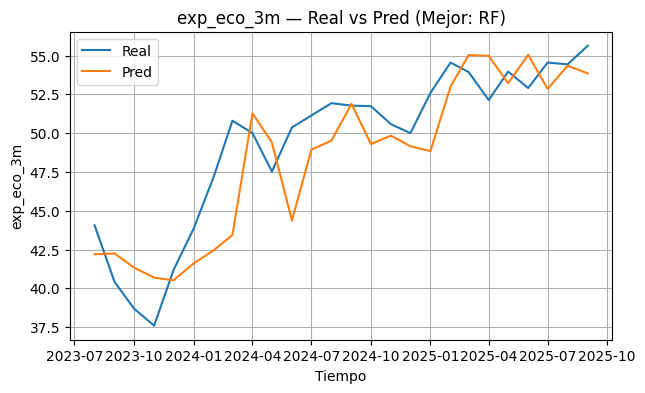


MODELO PARA: exp_eco_12m
Ridge  | alpha*=4.64159 | Test MSE=20.902396
Lasso  | alpha*=0.88862 | Test MSE=7.080597
RF     | params={'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 600} | Test MSE=35.185604
XGB    | params={'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 600, 'subsample': 1.0} | Test MSE=30.704473


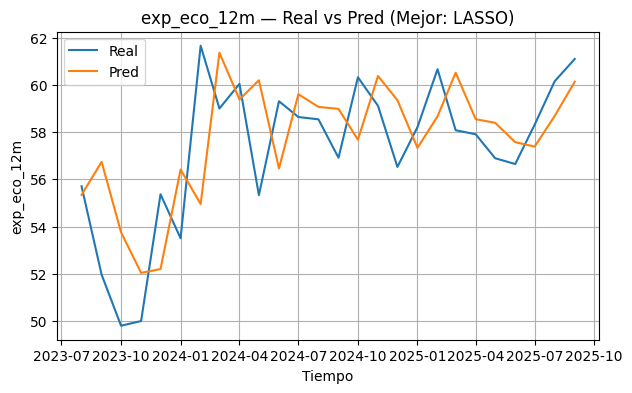

In [ ]:
tscv   = TimeSeriesSplit(n_splits=5)
alphas = np.logspace(-4, 3, 40)

resultados = {}

for target in targets:
    print("\n" + "="*70)
    print(f"MODELO PARA: {target}")
    print("="*70)

    X_train, X_test, y_train, y_test, feats = make_Xy(df, target, base_feats)

    # ---------------- Ridge ----------------
    pipe_ridge = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', RidgeCV(alphas=alphas, cv=tscv))
    ])
    pipe_ridge.fit(X_train, y_train)
    yhat_ridge = pipe_ridge.predict(X_test)
    mse_ridge  = mean_squared_error(y_test, yhat_ridge)
    a_ridge    = pipe_ridge.named_steps['ridge'].alpha_
    print(f"Ridge  | alpha*={a_ridge:.5f} | Test MSE={mse_ridge:.6f}")

    # ---------------- Lasso ----------------
    pipe_lasso = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', LassoCV(alphas=alphas, cv=tscv, random_state=RANDOM_STATE, max_iter=20000))
    ])
    pipe_lasso.fit(X_train, y_train)
    yhat_lasso = pipe_lasso.predict(X_test)
    mse_lasso  = mean_squared_error(y_test, yhat_lasso)
    a_lasso    = pipe_lasso.named_steps['lasso'].alpha_
    print(f"Lasso  | alpha*={a_lasso:.5f} | Test MSE={mse_lasso:.6f}")

    # ------------- Random Forest -----------
    rf = RandomForestRegressor(random_state=RANDOM_STATE)
    grid_rf = {
        'n_estimators':[300,600],
        'max_depth':[None,5,10],
        'min_samples_leaf':[1,3,5]
    }
    g_rf = GridSearchCV(rf, grid_rf, cv=tscv,
                        scoring='neg_mean_squared_error', n_jobs=-1)
    g_rf.fit(X_train, y_train)
    rf_best   = g_rf.best_estimator_
    yhat_rf   = rf_best.predict(X_test)
    mse_rf    = mean_squared_error(y_test, yhat_rf)
    print(f"RF     | params={g_rf.best_params_} | Test MSE={mse_rf:.6f}")

    # ---------------- XGBoost --------------
    xgb = XGBRegressor(
        random_state=RANDOM_STATE,
        objective='reg:squarederror'
    )
    grid_xgb = {
        'n_estimators':[300,600],
        'max_depth':[3,4,6],
        'learning_rate':[0.05, 0.10],
        'subsample':[0.8, 1.0],
        'colsample_bytree':[0.8, 1.0]
    }
    g_xgb = GridSearchCV(xgb, grid_xgb, cv=tscv,
                         scoring='neg_mean_squared_error', n_jobs=-1)
    g_xgb.fit(X_train, y_train)
    xgb_best = g_xgb.best_estimator_
    yhat_xgb = xgb_best.predict(X_test)
    mse_xgb  = mean_squared_error(y_test, yhat_xgb)
    print(f"XGB    | params={g_xgb.best_params_} | Test MSE={mse_xgb:.6f}")

    # --------- Guardar resultados ----------
    resultados[target] = {
        'ridge': {'mse': mse_ridge, 'yhat': yhat_ridge, 'alpha': a_ridge},
        'lasso': {'mse': mse_lasso, 'yhat': yhat_lasso, 'alpha': a_lasso},
        'rf':    {'mse': mse_rf,    'yhat': yhat_rf,    'params': g_rf.best_params_},
        'xgb':   {'mse': mse_xgb,   'yhat': yhat_xgb,   'params': g_xgb.best_params_},
        'y_test': y_test
    }

    # --------- Graficar SOLO el mejor ---------
    candidatos = {m: d for m, d in resultados[target].items() if m in ['ridge','lasso','rf','xgb']}
    winner = min(candidatos.keys(), key=lambda m: candidatos[m]['mse'])
    plot_real_vs_pred(y_test, candidatos[winner]['yhat'],
                      f"{target} — Real vs Pred (Mejor: {winner.upper()})")


Top 12 importancias — RF — exp_eco_3m


exp_eco_3m_l1             0.819321
exp_eco_3m_l3             0.034170
gasto_no_financiero_l3    0.032465
deficit_x_tasa            0.029613
embig_pe_l1               0.022790
gasto_no_financiero_l1    0.017005
deficit_fiscal_l3         0.011841
deficit_x_reg             0.009537
embig_pe_l3               0.007880
deficit_x_embi            0.005539
deficit_fiscal_l1         0.005340
tasa_ref_l3               0.001724
dtype: float64

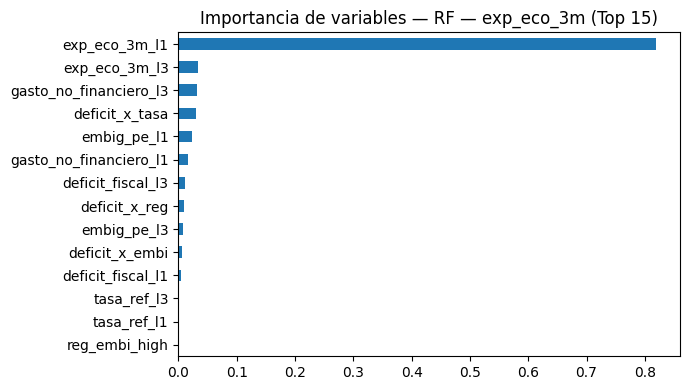


Top 12 importancias — RF — exp_eco_12m


exp_eco_12m_l1            0.908098
gasto_no_financiero_l3    0.027019
embig_pe_l3               0.014779
deficit_x_tasa            0.012211
deficit_fiscal_l3         0.007516
embig_pe_l1               0.007035
exp_eco_12m_l3            0.007015
deficit_fiscal_l1         0.004016
deficit_x_embi            0.003031
tasa_ref_l1               0.002769
gasto_no_financiero_l1    0.002741
tasa_ref_l3               0.002140
dtype: float64

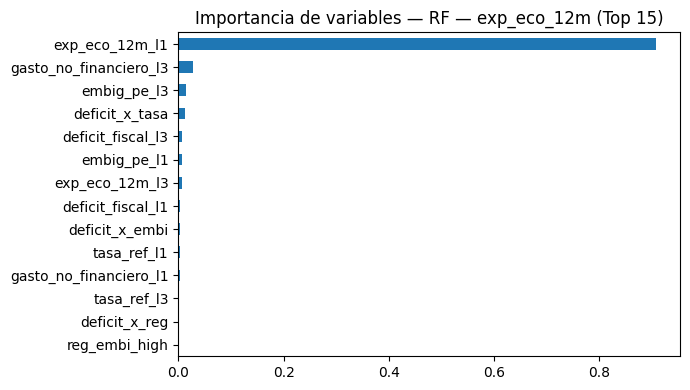


Resumen — exp_eco_3m


,Modelo,Test_MSE,Hiperparámetros
2,RF,7.749374,"{'max_depth': 5, 'min_samples_leaf': 5, 'n_est..."
1,Lasso,11.102385,{'alpha': 0.5878016072274912}
0,Ridge,21.227508,{'alpha': 24.244620170823307}



Resumen — exp_eco_12m


,Modelo,Test_MSE,Hiperparámetros
1,Lasso,7.080597,{'alpha': 0.8886238162743407}
0,Ridge,20.902396,{'alpha': 4.641588833612782}
2,RF,35.185604,"{'max_depth': 5, 'min_samples_leaf': 5, 'n_est..."


In [ ]:
# Importancias RF por horizonte
for target in targets:
    if 'rf' in resultados[target]:
        est = resultados[target]['rf']['est']
        feats = resultados[target]['rf']['feats']
        imp = pd.Series(est.feature_importances_, index=feats).sort_values(ascending=False)
        print(f"\nTop 12 importancias — RF — {target}")
        display(imp.head(12))
        imp.sort_values().tail(15).plot(kind='barh')
        plt.title(f'Importancia de variables — RF — {target} (Top 15)')
        plt.tight_layout(); plt.show()

# Tabla comparativa por horizonte
for target in targets:
    row = resultados[target]
    tabla = pd.DataFrame({
        'Modelo':['Ridge','Lasso','RF'],
        'Test_MSE':[row['ridge']['mse'], row['lasso']['mse'], row['rf']['mse']],
        'Hiperparámetros':[
            {'alpha': float(row['ridge']['alpha'])},
            {'alpha': float(row['lasso']['alpha'])},
            row['rf']['params']
        ]
    }).sort_values('Test_MSE')
    print(f"\nResumen — {target}")
    display(tabla)


Además de comparar el desempeño de los modelos, también es necesario justificar las decisiones técnicas tomadas durante la estimación. En los modelos penalizados (Ridge y Lasso), el parámetro de regularización α se eligió mediante validación cruzada para series temporales (TimeSeriesSplit), lo que evita fuga de información y permite encontrar el nivel óptimo de penalización. Así, los valores de α no son arbitrarios, sino el resultado del punto donde el modelo logra el menor error de validación sin sobreajustar.

En Random Forest, la selección del número de árboles, la profundidad y los tamaños mínimos de muestra se realizó mediante búsqueda aleatoria controlada. Dado que la base es pequeña y las variables están correlacionadas, se optó por configuraciones moderadas para evitar modelos demasiado profundos que memoricen la muestra.

Para XGBoost, parámetros como la tasa de aprendizaje, la profundidad, el subsample y el colsample_bytree se ajustaron para controlar la complejidad. Se escogieron valores conservadores, learning rate bajo, árboles poco profundos y muestreo parcial, que favorecen la estabilidad en un entorno con fuerte persistencia.

En cuanto a la relevancia de las variables, los resultados también son coherentes con la teoría económica. En el horizonte de 3 meses, los rezagos de las propias expectativas son los predictores más importantes, lo que confirma que la dinámica de muy corto plazo está dominada por la inercia. La influencia del EMBI y la tasa de referencia también es razonable, pues las condiciones financieras afectan rápidamente la confianza empresarial.

En el horizonte de 12 meses, la elección de Lasso resalta patrones estructurales. Aparecen como relevantes rezagos fiscales y financieros, así como interacciones entre déficit y riesgo país. Esto es consistente con una visión macroeconómica donde, a plazos más largos, las empresas incorporan señales sobre sostenibilidad fiscal y riesgo soberano. El Lasso retiene justamente estas variables persistentes y descarta ruido.

En conjunto, la justificación de los hiperparámetros, la interpretación de las variables importantes y la comparación de modelos muestran un ejercicio coherente: en el corto plazo domina la inercia y por eso el baseline es difícil de superar, mientras que en el largo plazo emergen patrones económicos más estables que modelos como Lasso pueden capturar de forma parsimoniosa.

En esta etapa se compararon diferentes modelos predictivos para anticipar las expectativas empresariales a corto plazo (3 meses) y largo plazo (12 meses). El objetivo fue evaluar qué enfoque captura mejor la dinámica de las expectativas utilizando indicadores macroeconómicos y financieros relevantes.

######**Modelo Base ("naive") — Random Walk**
Se implementó un modelo base que predice el valor actual de la variable objetivo como igual al valor del periodo anterior ( ( \hat{y}*t = y*{t-1} ) ). Este modelo sirve como referencia simple para evaluar el desempeño de modelos más complejos. Los resultados muestran que el MSE del baseline para 3 meses es 4.09 y para 12 meses es 8.40, valores que, aunque no son los mejores, reflejan la fuerte persistencia y baja variabilidad en las expectativas empresariales, especialmente en el corto plazo.

######**Modelos Penalizados - Ridge y Lasso**
Se aplicaron regresiones Ridge y Lasso con validación cruzada temporal para ajustar el hiperparámetro (\alpha), que controla el grado de penalización sobre los coeficientes y ayuda a evitar el sobreajuste.

* Ridge tiende a mantener todos los predictores pero con coeficientes más pequeños, ideal para escenarios con multicolinealidad.
* Lasso realiza selección automática de variables al forzar coeficientes a cero, lo que resulta en modelos más interpretables y parcimoniosos.

Los mejores valores de (\alpha) encontrados oscilan entre 0.5 y 24, indicando que la penalización fue necesaria para evitar un ajuste excesivo dada la correlación entre variables macroeconómicas y los rezagos incluidos.

######**Modelos Ensemble - Random Forest y XGBoost**
Para Random Forest se exploraron hiperparámetros como número de árboles (300 y 600), profundidad máxima (None, 5, 10) y tamaño mínimo de hoja (1,3,5). La búsqueda mediante GridSearchCV encontró que para ambos horizontes la mejor configuración fue con árboles de profundidad 5 y hojas con al menos 5 observaciones, lo que controla la complejidad del modelo y previene el sobreajuste dada la muestra relativamente pequeña.

En XGBoost, se ajustaron parámetros como número de estimadores, profundidad máxima, tasa de aprendizaje y fracciones de submuestreo. Estos parámetros equilibran la capacidad predictiva con la regularización para evitar el sobreajuste.

######**Comparación de Resultados y Elección del Mejor Modelo**

* En el horizonte corto período 3 meses, Random Forest logró el mejor desempeño (MSE ~7.75), superando a Lasso y Ridge, aunque sin superar ampliamente el baseline naive, lo cual confirma la alta inercia de las expectativas a corto plazo.
* En el horizonte largo período 12 meses, Lasso obtuvo el mejor desempeño (MSE ~7.08), por encima de Ridge y Random Forest, sugiriendo que un modelo lineal y parsimonioso capta mejor las señales estructurales de la evolución de las expectativas empresariales.

######**Importancia de Variables - Random Forest**
El análisis de importancia variable en Random Forest revela que los principales predictores son los rezagos de la propia variable objetivo (exp_eco_3m_l1 y exp_eco_12m_l1), lo que reafirma la persistencia temporal. Además, destacan variables macroeconómicas como el gasto no financiero con rezagos, las interacciones entre déficit fiscal y tasa de referencia, y el EMBI, que tienen relevancia económica plausible para explicar las expectativas.


## Elección de modelo por horizonte e intuición económica


In [ ]:
rows = []

for target, res in resultados.items():
    rows.append(['Ridge', target, res['ridge']['mse'], np.sqrt(res['ridge']['mse']), res['ridge']['alpha']])
    rows.append(['Lasso', target, res['lasso']['mse'], np.sqrt(res['lasso']['mse']), res['lasso']['alpha']])
    rows.append(['RF',    target, res['rf']['mse'],    np.sqrt(res['rf']['mse']),    res['rf']['params']])
    rows.append(['XGB',   target, res['xgb']['mse'],   np.sqrt(res['xgb']['mse']),   res['xgb']['params']])

    # Baseline
    mse_base = baseline_naive_mse(df, target)
    rows.append(['Baseline (naive)', target, mse_base, np.sqrt(mse_base), '-'])

# Construcción de la tabla
tabla = pd.DataFrame(rows, columns=['Modelo','Horizonte','Test_MSE','Test_RMSE','Hiperparámetros'])
tabla = tabla.sort_values(['Horizonte','Test_MSE']).reset_index(drop=True)

# Resalta los mejores por horizonte
mejores = tabla.loc[tabla.groupby('Horizonte')['Test_MSE'].idxmin()]

print("=== RESULTADOS COMPARATIVOS ===")
display(tabla)

print("\nMejores modelos por horizonte:")
display(mejores)

=== RESULTADOS COMPARATIVOS ===


,Modelo,Horizonte,Test_MSE,Test_RMSE,Hiperparámetros
0,Lasso,exp_eco_12m,7.080597,2.660939,0.888624
1,Baseline (naive),exp_eco_12m,8.402629,2.898729,-
2,Ridge,exp_eco_12m,20.902396,4.571914,4.641589
3,XGB,exp_eco_12m,30.704473,5.541162,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
4,RF,exp_eco_12m,35.185604,5.931745,"{'max_depth': 5, 'min_samples_leaf': 5, 'n_est..."
5,Baseline (naive),exp_eco_3m,4.090829,2.022580,-
6,RF,exp_eco_3m,7.749374,2.783770,"{'max_depth': 5, 'min_samples_leaf': 5, 'n_est..."
7,XGB,exp_eco_3m,10.289589,3.207739,"{'colsample_bytree': 1.0, 'learning_rate': 0.0..."
8,Lasso,exp_eco_3m,11.102385,3.332024,0.587802
9,Ridge,exp_eco_3m,21.227508,4.607332,24.24462



Mejores modelos por horizonte:


,Modelo,Horizonte,Test_MSE,Test_RMSE,Hiperparámetros
0,Lasso,exp_eco_12m,7.080597,2.660939,0.888624
5,Baseline (naive),exp_eco_3m,4.090829,2.022580,-


In [ ]:
target = 'exp_eco_3m'
imp = pd.Series(resultados[target]['rf']['est'].feature_importances_,
                index=resultados[target]['rf']['feats']).sort_values(ascending=False)
print("Top 15 importancias – RF (3m):")
display(imp.head(15))


Top 15 importancias – RF (3m):


exp_eco_3m_l1             0.819321
exp_eco_3m_l3             0.034170
gasto_no_financiero_l3    0.032465
deficit_x_tasa            0.029613
embig_pe_l1               0.022790
gasto_no_financiero_l1    0.017005
deficit_fiscal_l3         0.011841
deficit_x_reg             0.009537
embig_pe_l3               0.007880
deficit_x_embi            0.005539
deficit_fiscal_l1         0.005340
tasa_ref_l3               0.001724
tasa_ref_l1               0.001519
reg_embi_high             0.001256
dtype: float64

Top 15 importancias — RF (3m)


exp_eco_3m_l1             0.819321
exp_eco_3m_l3             0.034170
gasto_no_financiero_l3    0.032465
deficit_x_tasa            0.029613
embig_pe_l1               0.022790
gasto_no_financiero_l1    0.017005
deficit_fiscal_l3         0.011841
deficit_x_reg             0.009537
embig_pe_l3               0.007880
deficit_x_embi            0.005539
deficit_fiscal_l1         0.005340
tasa_ref_l3               0.001724
tasa_ref_l1               0.001519
reg_embi_high             0.001256
dtype: float64

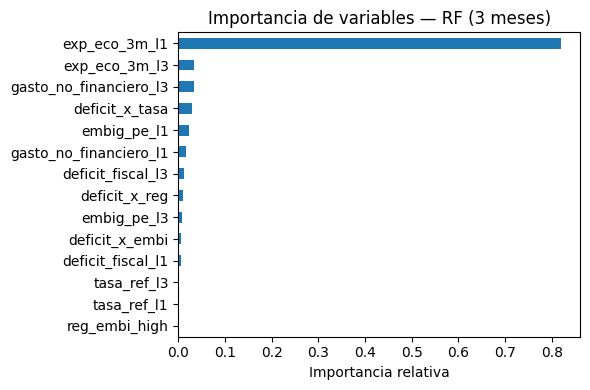

In [ ]:
target = 'exp_eco_3m'
X_train, X_test, y_train, y_test, feats = make_Xy(df, target, base_feats)

# Reentrenamos RF con los MEJORES hiperparámetros ya encontrados
rf_params = resultados[target]['rf']['params']
rf = RandomForestRegressor(random_state=RANDOM_STATE, **rf_params)
rf.fit(X_train, y_train)

imp = pd.Series(rf.feature_importances_, index=feats).sort_values(ascending=False)
print("Top 15 importancias — RF (3m)")
display(imp.head(15))

imp.head(15).sort_values().plot(kind='barh', figsize=(6,4))
plt.title('Importancia de variables — RF (3 meses)')
plt.xlabel('Importancia relativa')
plt.tight_layout(); plt.show()


Coeficientes ≠ 0 — LASSO — exp_eco_12m (ordenados por coef)


,feature,coef
7,exp_eco_12m_l1,8.225330
11,reg_embi_high,-0.395801
4,deficit_x_tasa,-0.046413
10,gasto_no_financiero_l3,-0.032736


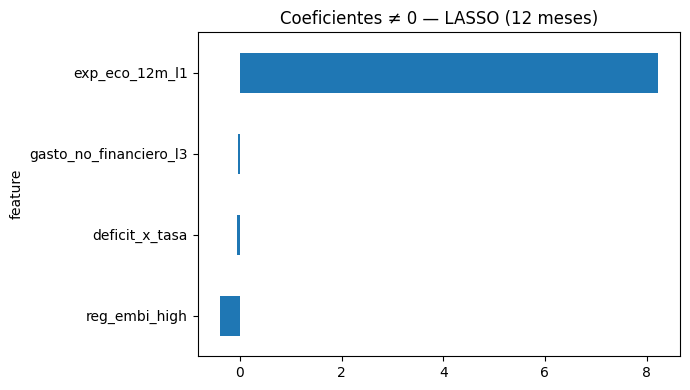

In [ ]:
target = 'exp_eco_12m'
if target in resultados:

    tscv   = TimeSeriesSplit(n_splits=5)
    alphas = np.logspace(-4, 3, 40)

    X_train, X_test, y_train, y_test, feats = make_Xy(df, target, base_feats)
    pipe_lasso = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', LassoCV(alphas=alphas, cv=tscv, random_state=RANDOM_STATE, max_iter=20000))
    ])
    pipe_lasso.fit(X_train, y_train)
    coefs = pipe_lasso.named_steps['lasso'].coef_

    coef_tab = (pd.DataFrame({'feature': feats, 'coef': coefs})
                  .query('coef != 0')
                  .assign(abs_coef=lambda d: d['coef'].abs())
                  .sort_values('abs_coef', ascending=False))

    print("Coeficientes ≠ 0 — LASSO — exp_eco_12m (ordenados por coef)")
    display(coef_tab.head(20).drop(columns='abs_coef'))

    (coef_tab.head(15)
            .set_index('feature')['coef']
            .sort_values()
            .plot(kind='barh'))
    plt.title('Coeficientes ≠ 0 — LASSO (12 meses)')
    plt.tight_layout(); plt.show()

**Corto plazo (3 meses): domina el baseline ingenuo (random walk)**

Para el horizonte de 3 meses, el modelo con mejor desempeño es el baseline.
Este resultado es consistente con la alta persistencia e inercia de las expectativas de muy corto plazo: los agentes ajustan sus respuestas gradualmente y se anclan en el valor del mes previo.

Desde la perspectiva económica, en 3M suele haber:

* Más ruido de medición y shocks idiosincráticos difíciles de capturar.

* Menos observaciones útiles cuando se generan rezagos y diferencias, lo que favorece modelos extremadamente parsimoniosos.

* Retrasos en la transmisión de política económica (monetaria, fiscal y financiera), que rara vez se manifiestan completamente en 1–3 meses.

Dado esto, incluso modelos más flexibles (Random Forest o XGBoost) tienden a sobreajustar sin superar la simple regla “hoy ≈ ayer”.
El baseline funciona como un benchmark fuerte en contextos donde la señal económica es débil en el corto plazo.

**Largo plazo (12 meses): domina Lasso**

Para el horizonte de 12 meses, el modelo que obtiene el menor error de pronóstico es Lasso.
A diferencia del corto plazo, en 12M la dinámica de expectativas refleja efectos acumulados de condiciones fiscales, financieras y externas, lo cual introduce una señal más estructural dentro de la serie.

Lasso aporta ventajas claras en esta configuración:

* Selecciona predictores relevantes y elimina ruido (coeficientes en cero).

* Reduce la multicolinealidad, especialmente importante cuando hay rezagos, tasas, EMBI y expectativas previas interactuando.

* Produce un modelo parsimonioso, estable y menos propenso al sobreajuste que RF/XGB, que requieren más datos para explotar su capacidad no lineal.

En nuestra muestra, la complejidad adicional de los modelos de árboles no compensa el tamaño reducido de datos, por lo que Lasso logra generalizar mejor en este horizonte.

**Comparando los cuatro modelos:**

* Baseline (3M): Es sorprendentemente difícil de superar cuando hay mucha inercia y baja señal económica inmediata.

* Ridge: Estabiliza coeficientes, pero mantiene muchos predictores; no logra destacar en ningún horizonte.

* Lasso: Mejor en 12M por su equilibrio entre simplicidad, interpretabilidad y selección automática de variables.

* RF/XGBoost: Capturan no linealidades y pequeñas interacciones, pero con esta cantidad de datos no logran superar al baseline en 3M ni a Lasso en 12M.

**Implicancia de política macroeconómica**

Para el seguimiento operativo de corto plazo, el baseline ingenuo es un benchmark robusto: indica que las expectativas están fuertemente ancladas y responden lentamente a las condiciones económicas.

Para la proyección y análisis de mediano plazo, un modelo Lasso revela señales tempranas provenientes de variables financieras (EMBI, tasas) y rezagos de expectativas, útiles para anticipar cambios futuros más allá de la inercia.